# Healthcare Analytics: From Patient Journey to Action

## Problem statement

A multi-hospital group across Delhi NCR and Bihar needs to know where to act. Volume is rising, but leadership cannot see which levers matter. This notebook sits on top of the SQL analysis and answers three decision questions:

1. **Demand** is patient volume growing, and where?
2. **Revenue** how much billed value is going uncollected, and through whom?
3. **Cost** where is the money actually being spent?

Each question ends in a recommendation, not just a chart.

## Demand: encounters per year

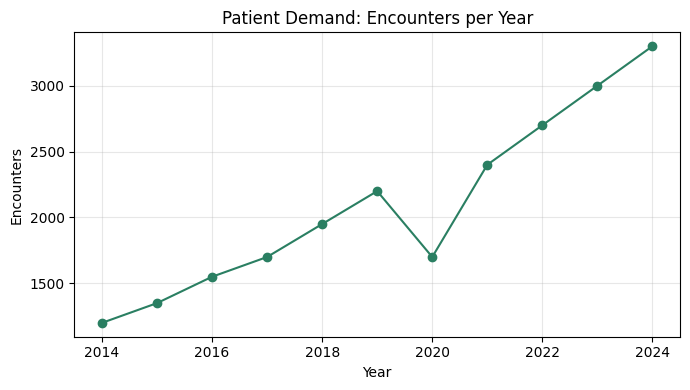

In [2]:
enc['year'] = pd.to_datetime(enc['start_datetime']).dt.year
yearly = enc.groupby('year').size()
plt.figure(figsize=(7,4))
plt.plot(yearly.index, yearly.values, marker='o', color='#2a7f62')
plt.title('Patient Demand: Encounters per Year')
plt.xlabel('Year'); plt.ylabel('Encounters'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Insight.** Demand nearly tripled, from 1,200 encounters in 2014 to 3,300 in 2024, with a dip in 2020. Ambulatory visits are half of all volume, so growth is outpatient-led.

## Revenue: uncovered billing by payer type

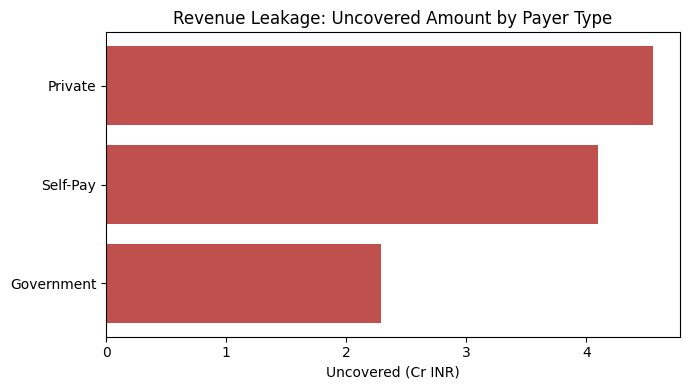

In [3]:
enc['uncovered'] = enc['total_claim_cost'] - enc['payer_coverage']
u = (enc.merge(pay, on='payer_id')
        .groupby('payer_type')['uncovered'].sum() / 1e7).sort_values()
plt.figure(figsize=(7,4))
plt.barh(u.index, u.values, color='#c0504d')
plt.title('Revenue Leakage: Uncovered Amount by Payer Type')
plt.xlabel('Uncovered (Cr INR)'); plt.tight_layout(); plt.show()

**Insight.** Of 19.61 Cr billed, 10.94 Cr (55.8%) is uncovered, led by Private payers (4.55 Cr) and Self-Pay (4.10 Cr). This is a collections and eligibility problem.

## Cost: where the money is spent

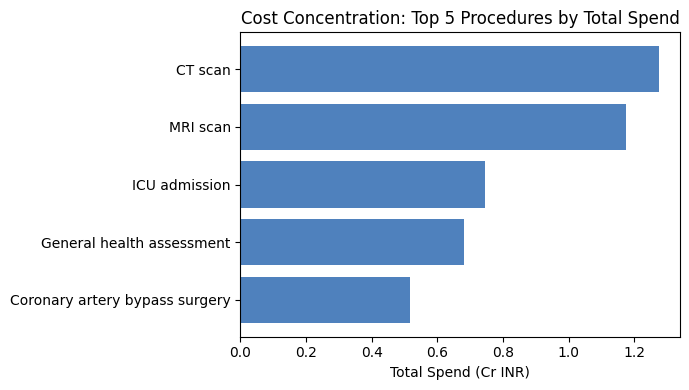

In [4]:
top = (proc.groupby('procedure_desc')['cost'].sum() / 1e7)\
          .sort_values(ascending=False).head(5)
plt.figure(figsize=(7,4))
plt.barh(top.index[::-1], top.values[::-1], color='#4f81bd')
plt.title('Cost Concentration: Top 5 Procedures by Total Spend')
plt.xlabel('Total Spend (Cr INR)'); plt.tight_layout(); plt.show()

**Insight.** The top three procedure types carry 41% of all procedure spend, led by CT and MRI imaging plus ICU admission, not by rare high-priced surgeries. Cost control belongs on high-volume imaging and ICU length of stay.

## Recommendations

| Lever | Finding | Action |
|---|---|---|
| Demand | ~175% growth, ambulatory-led, half of volume | Index staffing and OPD capacity to the ambulatory line, not inpatient beds |
| Revenue | 55.8% of billing uncovered; Private and Self-Pay lead | Point-of-care eligibility checks; collect Self-Pay at discharge |
| Cost | Top 3 procedures = 41% of spend, led by imaging and ICU | Imaging utilisation review and ICU stay protocols; renegotiate imaging rates |
| Operations | 90 patients drive the 30-day readmissions (from SQL) | Targeted post-discharge follow-up for that cohort |


## Expected impact

The three levers point to one conclusion: this network's risk is financial, not clinical-volume. Recovering part of the 10.94 Cr uncovered billing, trimming imaging and ICU cost, and following up the 90 high-readmission patients would move margin more than any further increase in volume. The recommendation to leadership is to prioritise collections and cost control over capacity expansion.